In [1]:
import os
import geopandas as gpd
print(os.getcwd())

d:\ENSAE Paris\3A\S1\ML_Climate_risk\PROJET\ML_For_Climate_risk\ML-for-Climate-Risk\ANA_EXPLO


In [2]:
LimitAdmin = r"D:\ENSAE Paris\3A\S1\ML_Climate_risk\Nouveau dossier\Bases\ADE_4-0_GPKG_LAMB93_FXX-ED2025-10-15.gpkg"
gdf_regions = gpd.read_file(LimitAdmin, layer="region").to_crs(2154)

In [3]:
import pandas as pd

data = pd.read_csv("../data/data_cleaned.csv", sep=",")
data.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_20228\619631920.py:3: DtypeWarning: Columns (6,10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/data_cleaned.csv", sep=",")


,NUMERO,LAMBX_93,LAMBY_93,LAMBX_2,LAMBY_2,ANNEE,code_insee_commune,commune,code_insee_de_la_region,region,...,WG_RACINE_03,WG_RACINE_04,WG_RACINE_05,WG_RACINE_06,WG_RACINE_07,WG_RACINE_08,WG_RACINE_09,WG_RACINE_10,WG_RACINE_11,WG_RACINE_12
0,1860,111467,6838785,60000,2401000,2000,29084,Île-Molène,53,Bretagne,...,0.30,0.30,0.30,0.29,0.28,0.26,0.25,0.28,0.31,0.32
1,2477,127137,6798687,76000,2361000,2000,29168,Plogoff,53,Bretagne,...,0.23,0.24,0.23,0.22,0.19,0.18,0.18,0.21,0.25,0.27
2,1984,127392,6830663,76000,2393000,2000,29190,Plougonvelin,53,Bretagne,...,0.29,0.29,0.29,0.27,0.25,0.23,0.23,0.26,0.30,0.32
3,1861,127455,6838657,76000,2401000,2000,29201,Ploumoguer,53,Bretagne,...,0.30,0.31,0.30,0.29,0.27,0.25,0.24,0.28,0.32,0.33
4,1737,127519,6846652,76000,2409000,2000,29098,Lampaul-Plouarzel,53,Bretagne,...,0.30,0.31,0.30,0.29,0.27,0.24,0.24,0.28,0.32,0.33


In [4]:
print(data.columns.tolist())

['NUMERO', 'LAMBX_93', 'LAMBY_93', 'LAMBX_2', 'LAMBY_2', 'ANNEE', 'code_insee_commune', 'commune', 'code_insee_de_la_region', 'region', 'code_insee_departement', 'departement', 'argile_niveau', 'swi_unif_01', 'swi_unif_02', 'swi_unif_03', 'swi_unif_04', 'swi_unif_05', 'swi_unif_06', 'swi_unif_07', 'swi_unif_08', 'swi_unif_09', 'swi_unif_10', 'swi_unif_11', 'swi_unif_12', 'SWI_01', 'SWI_02', 'SWI_03', 'SWI_04', 'SWI_05', 'SWI_06', 'SWI_07', 'SWI_08', 'SWI_09', 'SWI_10', 'SWI_11', 'SWI_12', 'DLI_01', 'DLI_02', 'DLI_03', 'DLI_04', 'DLI_05', 'DLI_06', 'DLI_07', 'DLI_08', 'DLI_09', 'DLI_10', 'DLI_11', 'DLI_12', 'DRAINC_01', 'DRAINC_02', 'DRAINC_03', 'DRAINC_04', 'DRAINC_05', 'DRAINC_06', 'DRAINC_07', 'DRAINC_08', 'DRAINC_09', 'DRAINC_10', 'DRAINC_11', 'DRAINC_12', 'ECOULEMENT_01', 'ECOULEMENT_02', 'ECOULEMENT_03', 'ECOULEMENT_04', 'ECOULEMENT_05', 'ECOULEMENT_06', 'ECOULEMENT_07', 'ECOULEMENT_08', 'ECOULEMENT_09', 'ECOULEMENT_10', 'ECOULEMENT_11', 'ECOULEMENT_12', 'ETP_01', 'ETP_02', 'ETP_0

In [5]:
import pandas as pd

# --- Colonnes mensuelles ---
cols_swi = [f"SWI_{str(m).zfill(2)}" for m in range(1, 13)]
cols_unif = [f"swi_unif_{str(m).zfill(2)}" for m in range(1, 13)]

# --- Conversion en format long ---
df_long = data.melt(
    id_vars=["NUMERO", "ANNEE", "code_insee_departement", "code_insee_de_la_region"],
    value_vars=cols_swi + cols_unif,
    var_name="variable",
    value_name="valeur"
)

# Extraction du mois (01 → 1) et du type (SWI ou swi_unif)
df_long["mois"] = df_long["variable"].str[-2:].astype(int)
df_long["type"] = df_long["variable"].str.replace(r"_[0-9]{2}$", "", regex=True)

# Pivot long → tidy panel
df_panel = df_long.pivot_table(
    index=["NUMERO", "ANNEE", "mois", "code_insee_departement", "code_insee_de_la_region"],
    columns="type",
    values="valeur"
).reset_index()

# Ajouter la date si utile
df_panel["date"] = pd.to_datetime(
    df_panel["ANNEE"].astype(str) + "-" + df_panel["mois"].astype(str) + "-01"
)

df_panel.head()



type,NUMERO,ANNEE,mois,code_insee_departement,code_insee_de_la_region,SWI,swi_unif,date
0,2,2000,1,59,32,0.93,0.976,2000-01-01
1,2,2000,2,59,32,0.84,0.928,2000-02-01
2,2,2000,3,59,32,0.75,0.876,2000-03-01
3,2,2000,4,59,32,0.75,0.861,2000-04-01
4,2,2000,5,59,32,0.77,0.843,2000-05-01


In [6]:
print(df_panel.shape)

(2695920, 8)


In [7]:
import numpy as np

def corr_temporelle(sub):
    sub = sub[["SWI", "swi_unif"]].dropna()
    if len(sub) < 3:
        return np.nan
    return sub.corr().iloc[0, 1]


In [8]:
corr_maille = df_panel.groupby("NUMERO").apply(corr_temporelle)
corr_maille = corr_maille.rename("corr_maille")

print("Statistiques sur les corrélations par maille :")
print(corr_maille.describe())

corr_maille.head(30)


Statistiques sur les corrélations par maille :
count    8981.000000
mean        0.973429
std         0.017722
min         0.705895
25%         0.963723
50%         0.978167
75%         0.986869
max         0.997912
Name: corr_maille, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_20228\2047759300.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_maille = df_panel.groupby("NUMERO").apply(corr_temporelle)


NUMERO
2     0.888239
3     0.899136
4     0.922689
5     0.951138
6     0.965465
12    0.940259
13    0.945944
14    0.942959
15    0.941992
16    0.939874
17    0.951813
18    0.950485
19    0.985551
25    0.954425
26    0.967624
27    0.966445
28    0.950793
29    0.946537
30    0.945630
31    0.945522
32    0.946941
33    0.977944
37    0.974179
38    0.979411
39    0.981872
40    0.981027
41    0.975168
42    0.974400
43    0.963905
44    0.952791
Name: corr_maille, dtype: float64

In [9]:
corr_maille.info()

<class 'pandas.core.series.Series'>
Index: 8981 entries, 2 to 9892
Series name: corr_maille
Non-Null Count  Dtype  
--------------  -----  
8981 non-null   float64
dtypes: float64(1)
memory usage: 140.3 KB


In [10]:
data['NUMERO'].nunique()

8981

## Niveau département

In [11]:
df_dep = df_panel[["NUMERO", "code_insee_departement"]].drop_duplicates()

corr_dep = df_dep.merge(corr_maille, on="NUMERO") \
                 .groupby("code_insee_departement")["corr_maille"] \
                 .mean()

corr_dep = corr_dep.rename("corr_departement")

print("Statistiques par département :")
print(corr_dep.describe())

corr_dep.head()


Statistiques par département :
count    138.000000
mean       0.973940
std        0.011463
min        0.922011
25%        0.964851
50%        0.977443
75%        0.982411
max        0.991503
Name: corr_departement, dtype: float64


code_insee_departement
1    0.985868
2    0.964659
3    0.982281
4    0.976032
5    0.969087
Name: corr_departement, dtype: float64

## Niveau Région

In [12]:
df_reg = df_panel[["NUMERO", "code_insee_de_la_region"]].drop_duplicates()

corr_region = df_reg.merge(corr_maille, on="NUMERO") \
                    .groupby("code_insee_de_la_region")["corr_maille"] \
                    .mean()

corr_region = corr_region.rename("corr_region")

print("Statistiques par région :")
print(corr_region.describe())

corr_region.head()


Statistiques par région :
count    13.000000
mean      0.972954
std       0.008466
min       0.956844
25%       0.968623
50%       0.975240
75%       0.977253
max       0.985438
Name: corr_region, dtype: float64


code_insee_de_la_region
11    0.961874
24    0.956844
27    0.980943
28    0.977253
32    0.961316
Name: corr_region, dtype: float64

In [13]:
print(gdf_regions.columns.tolist())

['cleabs', 'nom_officiel', 'nom_officiel_en_majuscules', 'code_insee', 'code_siren', 'geometry']


C:\Users\USER\AppData\Local\Temp\ipykernel_20228\861658068.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_maille = df_panel.groupby("NUMERO").apply(corr_temporelle)


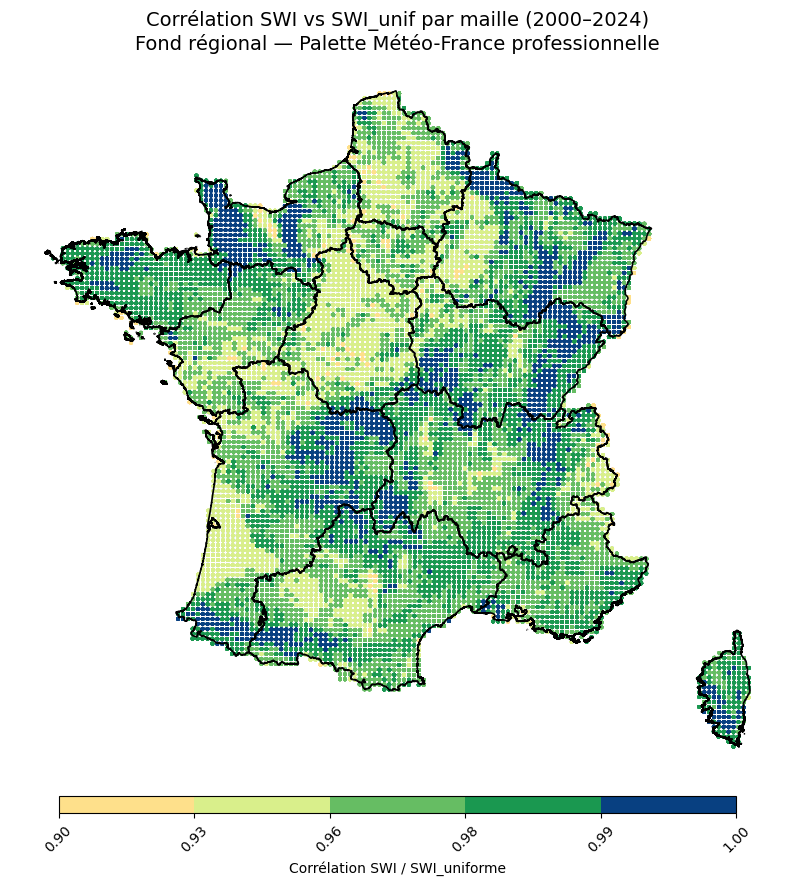

In [14]:
# ============================================================
# 0. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors



# ============================================================
# 1. CONSTRUCTION DE LA GEO-DATAFRAME DES MAILLES
# ============================================================

# data contient : NUMERO, LAMBX_93, LAMBY_93, SWI_01..., swi_unif_12, etc.
df = data.copy()
df["NUMERO"] = df["NUMERO"].astype(int)

# Création des géométries point (Lambert-93)
geometry = [Point(xy) for xy in zip(df["LAMBX_93"], df["LAMBY_93"])]
gdf_mailles = gpd.GeoDataFrame(df[["NUMERO"]], geometry=geometry, crs=2154)



# ============================================================
# 2. PASSAGE EN FORMAT PANEL LONG (comme tu faisais)
# ============================================================

cols_swi = [f"SWI_{str(m).zfill(2)}" for m in range(1, 13)]
cols_unif = [f"swi_unif_{str(m).zfill(2)}" for m in range(1, 13)]

df_long = df.melt(
    id_vars=["NUMERO", "ANNEE", "code_insee_departement", "code_insee_de_la_region"],
    value_vars=cols_swi + cols_unif,
    var_name="variable",
    value_name="valeur"
)

df_long["mois"] = df_long["variable"].str[-2:].astype(int)
df_long["type"] = df_long["variable"].str.replace(r"_[0-9]{2}$", "", regex=True)

df_panel = df_long.pivot_table(
    index=["NUMERO", "ANNEE", "mois", "code_insee_departement", "code_insee_de_la_region"],
    columns="type",
    values="valeur"
).reset_index()

df_panel["date"] = pd.to_datetime(df_panel["ANNEE"].astype(str) + "-" +
                                  df_panel["mois"].astype(str) + "-01")



# ============================================================
# 3. CALCUL DES CORRÉLATIONS PAR MAILLE
# ============================================================

def corr_temporelle(sub):
    sub = sub[["SWI", "swi_unif"]].dropna()
    if len(sub) < 3:
        return np.nan
    return sub.corr().iloc[0, 1]

corr_maille = df_panel.groupby("NUMERO").apply(corr_temporelle)
corr_maille = corr_maille.rename("corr").reset_index()



# ============================================================
# 4. JOINDRE LA CORRÉLATION AUX MAILLES (POINTS)
# ============================================================

gdf_corr_mailles = gdf_mailles.merge(corr_maille, on="NUMERO", how="left")



# ============================================================
# 5. CHARGER LE DÉCOUPAGE RÉGIONAL
# ============================================================

LimitAdmin = r"D:\ENSAE Paris\3A\S1\ML_Climate_risk\Nouveau dossier\Bases\ADE_4-0_GPKG_LAMB93_FXX-ED2025-10-15.gpkg"
gdf_regions = gpd.read_file(LimitAdmin, layer="region").to_crs(2154)
gdf_regions["code_insee"] = gdf_regions["code_insee"].astype(str)



# ============================================================
# 6. PALETTE MÉTÉO-FRANCE SPÉCIALE (corrélations élevées)
# ============================================================

# Classes pour distinguer 0.90 / 0.93 / 0.96 / 0.98 / 0.99 / 1.00
bins = [0.90, 0.93, 0.96, 0.98, 0.99, 1.00]

# Palette MF sols / sécheresse
colors_mf = ["#fee08b", "#d9ef8b", "#66bd63", "#1a9850", "#006837", "#084081"]

cmap_mf = mcolors.ListedColormap(colors_mf)
norm = mcolors.BoundaryNorm(bins, ncolors=cmap_mf.N)



# ============================================================
# 7. CARTE FINALE : MAILLES + FRONTIÈRES RÉGIONALES
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 11))

# ---- LES MAILLES ----
gdf_corr_mailles.plot(
    column="corr",
    ax=ax,
    cmap=cmap_mf,
    norm=norm,
    markersize=3,     # Ajuste si trop dense / trop fin
    alpha=0.85
)

# ---- FRONTIÈRES RÉGIONALES ----
gdf_regions.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

ax.set_title(
    "Corrélation SWI vs SWI_unif par maille (2000–2024)\n"
    "Fond régional — Palette Météo-France professionnelle",
    fontsize=14
)
ax.axis("off")

# ---- Colorbar fine, professionnelle ----
sm = plt.cm.ScalarMappable(cmap=cmap_mf, norm=norm)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.02,   # réduit fortement la hauteur
    pad=0.02,        # rapproche de la carte
    aspect=40,       # rend la barre longue et très mince
    ticks=bins
)

# Labels propres
cbar.ax.set_xticklabels([f"{b:.2f}" for b in bins], rotation=45)
cbar.set_label("Corrélation SWI / SWI_uniforme", fontsize=10)


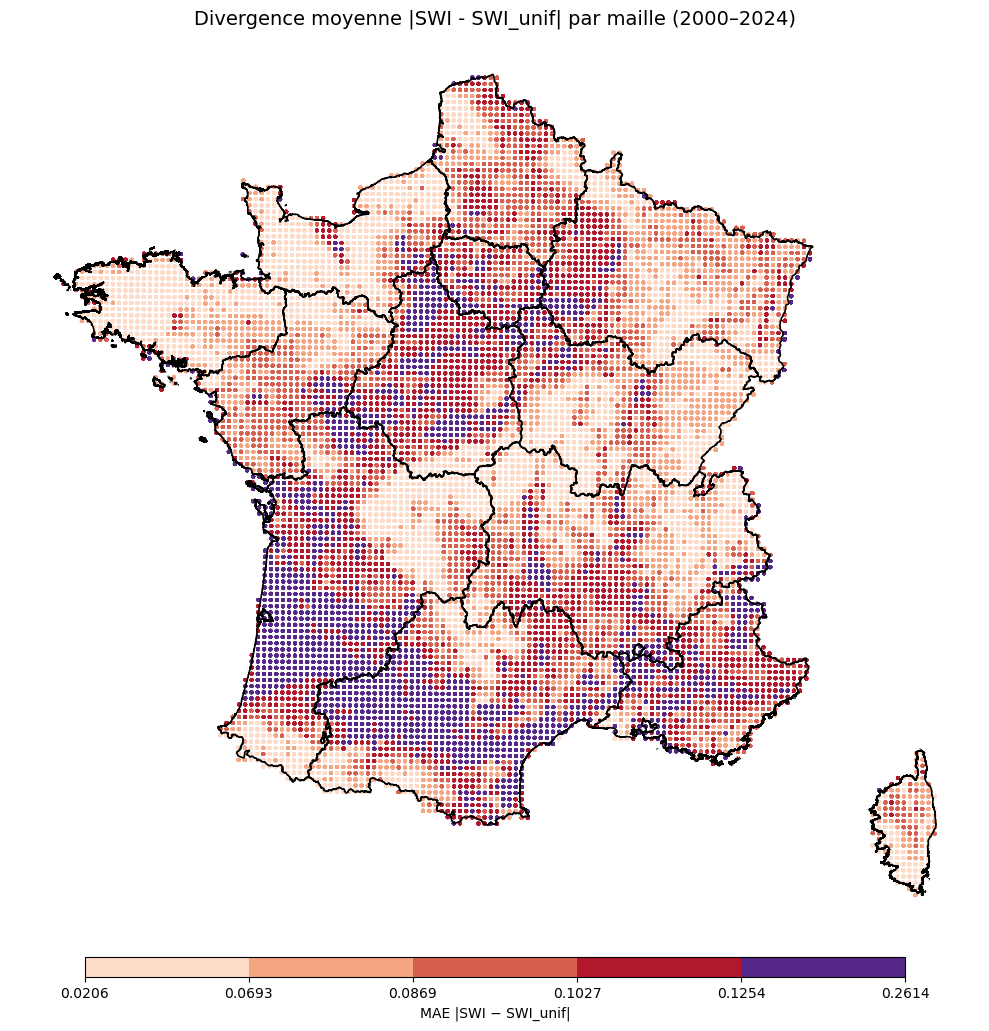

In [15]:
# ============================================================
# 0. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors



# ============================================================
# 1. CRÉATION DE LA GEO-DATAFRAME DES MAILLES
# ============================================================

df = data.copy()
df["NUMERO"] = df["NUMERO"].astype(int)

geometry = [Point(xy) for xy in zip(df["LAMBX_93"], df["LAMBY_93"])]
gdf_mailles = gpd.GeoDataFrame(df[["NUMERO"]], geometry=geometry, crs=2154)



# ============================================================
# 2. FORMAT PANEL LONG (pour reconstruire les séries temporelles)
# ============================================================

cols_swi = [f"SWI_{str(m).zfill(2)}" for m in range(1, 13)]
cols_unif = [f"swi_unif_{str(m).zfill(2)}" for m in range(1, 13)]

df_long = df.melt(
    id_vars=["NUMERO", "ANNEE", "code_insee_departement", "code_insee_de_la_region"],
    value_vars=cols_swi + cols_unif,
    var_name="variable",
    value_name="valeur"
)

df_long["mois"] = df_long["variable"].str[-2:].astype(int)
df_long["type"] = df_long["variable"].str.replace(r"_[0-9]{2}$", "", regex=True)

df_panel = df_long.pivot_table(
    index=["NUMERO", "ANNEE", "mois"],
    columns="type",
    values="valeur"
).reset_index()

df_panel["date"] = pd.to_datetime(df_panel["ANNEE"].astype(str) + "-" +
                                  df_panel["mois"].astype(str) + "-01")



# ============================================================
# 3. CALCUL DIVERGENCE MAE |SWI - SWI_unif| PAR MAILLE
# ============================================================

df_panel["abs_diff"] = (df_panel["SWI"] - df_panel["swi_unif"]).abs()

mae_maille = df_panel.groupby("NUMERO")["abs_diff"] \
                     .mean() \
                     .rename("mae") \
                     .reset_index()



# ============================================================
# 4. JOINDRE MAE AUX MAILLES (points)
# ============================================================

gdf_mae_mailles = gdf_mailles.merge(mae_maille, on="NUMERO", how="left")



# ============================================================
# 5. FRONTIÈRES RÉGIONALES
# ============================================================

LimitAdmin = r"D:\ENSAE Paris\3A\S1\ML_Climate_risk\Nouveau dossier\Bases\ADE_4-0_GPKG_LAMB93_FXX-ED2025-10-15.gpkg"
gdf_regions = gpd.read_file(LimitAdmin, layer="region").to_crs(2154)



# ============================================================
# 6. PALETTE MÉTÉO-FRANCE POUR LA DIVERGENCE
# ============================================================

# quantiles = classes naturelles MAE
quantiles_mae = np.quantile(gdf_mae_mailles["mae"], [0, 0.20, 0.40, 0.60, 0.80, 1])

# Palette utilisée par MF (sols / hydrologie)
colors_mae = ["#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#542788"]
cmap_mae = mcolors.ListedColormap(colors_mae)
norm_mae = mcolors.BoundaryNorm(quantiles_mae, ncolors=cmap_mae.N)



# ============================================================
# 7. CARTE FINALE — UNIQUEMENT LA DIVERGENCE
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 11))

# Mailles colorées par divergence
gdf_mae_mailles.plot(
    column="mae",
    ax=ax,
    cmap=cmap_mae,
    norm=norm_mae,
    markersize=3,
    alpha=0.85
)

# Frontières régionales
gdf_regions.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

ax.set_title(
    "Divergence moyenne |SWI - SWI_unif| par maille (2000–2024)",
    fontsize=14
)
ax.axis("off")

# ---- Colorbar fine et élégante ----
sm = plt.cm.ScalarMappable(cmap=cmap_mae, norm=norm_mae)
sm._A = []
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.02,
    pad=0.02,
    aspect=40
)
cbar.set_label("MAE |SWI − SWI_unif|", fontsize=10)

plt.tight_layout()
plt.show()


In [16]:
gdf_mae_mailles.head()

,NUMERO,geometry,mae
0,1860,POINT (111467 6838785),0.117343
1,2477,POINT (127137 6798687),0.074170
2,1984,POINT (127392 6830663),0.094110
3,1861,POINT (127455 6838657),0.069790
4,1737,POINT (127519 6846652),0.067010


In [17]:
corr_maille.head()

,NUMERO,corr
0,2,0.888239
1,3,0.899136
2,4,0.922689
3,5,0.951138
4,6,0.965465


c:\Users\USER\miniconda3\envs\_envclr\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


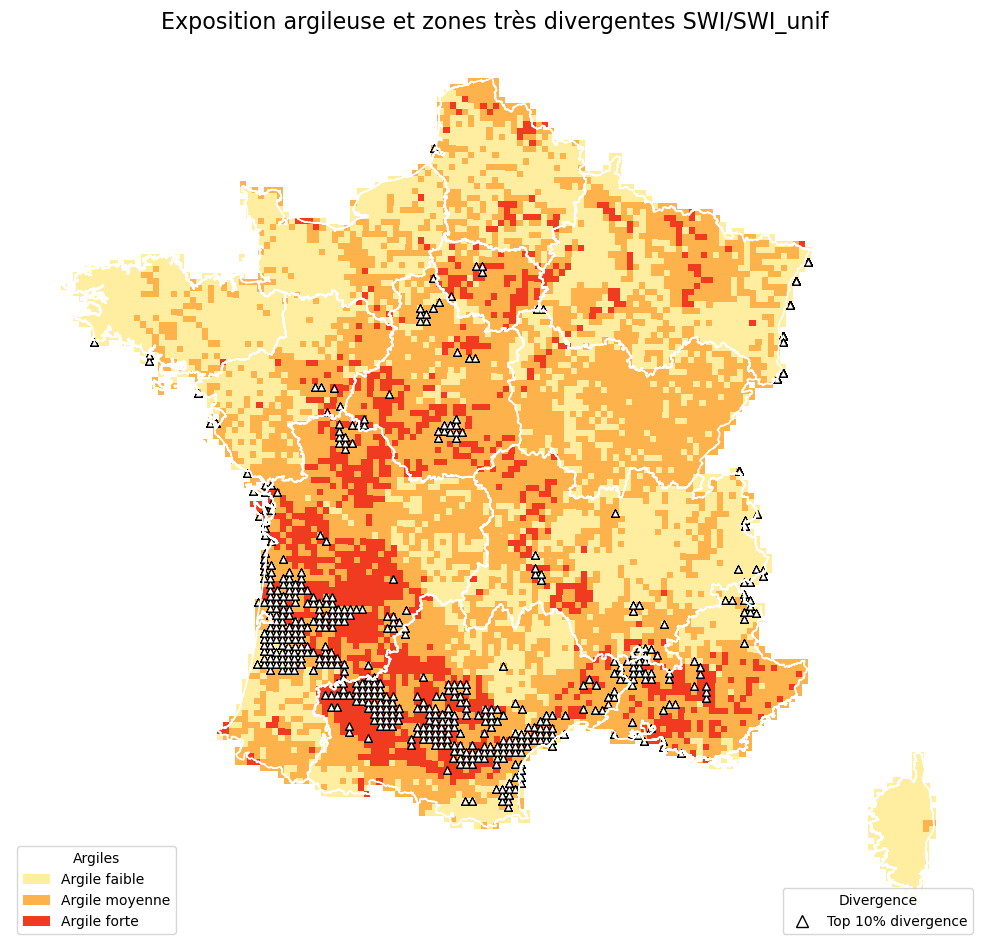

In [18]:
# ============================================================
# 0. Imports
# ============================================================
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# 1. Construire tuiles polygonales
# ============================================================

gdf_pts = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data["LAMBX_93"], data["LAMBY_93"]),
    crs=2154
)

MAILLE = 8000  # approx SWI grid

def make_tile(pt, d):
    x, y = pt.x, pt.y
    return Polygon([(x-d, y-d), (x+d, y-d), (x+d, y+d), (x-d, y+d)])

gdf_tiles = gdf_pts.copy()
gdf_tiles["geometry"] = gdf_pts.geometry.apply(lambda p: make_tile(p, MAILLE/2))


# ============================================================
# 2. Calcul MAE
# ============================================================

cols_swi  = [f"SWI_{str(m).zfill(2)}"      for m in range(1,13)]
cols_unif = [f"swi_unif_{str(m).zfill(2)}" for m in range(1,13)]

df_m = data.melt(
    id_vars=["NUMERO","ANNEE"],
    value_vars=cols_swi + cols_unif,
    var_name="var",
    value_name="val"
)

df_m["mois"] = df_m["var"].str[-2:].astype(int)
df_m["type"] = df_m["var"].str.replace(r"_[0-9]{2}$","",regex=True)

panel = df_m.pivot_table(
    index=["NUMERO","ANNEE","mois"],
    columns="type",
    values="val"
).reset_index()

panel["abs_diff"] = (panel["SWI"] - panel["swi_unif"]).abs()

mae = panel.groupby("NUMERO")["abs_diff"].mean().rename("mae").reset_index()
gdf_tiles = gdf_tiles.merge(mae, on="NUMERO", how="left")


# ============================================================
# 3. Couleurs BRGM saturées
# ============================================================

cmap_arg = mcolors.ListedColormap([
    "#FFEDA0",  # jaune saturé
    "#FEB24C",  # orange saturé
    "#F03B20"   # rouge saturé
])
norm_arg = mcolors.BoundaryNorm([1,2,3,4], cmap_arg.N)


# ============================================================
# 4. Top 10% divergences
# ============================================================

seuil = gdf_tiles["mae"].quantile(0.90)
gdf_div = gdf_tiles[gdf_tiles["mae"] >= seuil]

# centroïdes des polygones pour tracer les symboles
gdf_div["centroid"] = gdf_div.geometry.centroid
x = gdf_div["centroid"].x
y = gdf_div["centroid"].y


LimitAdmin = r"D:\ENSAE Paris\3A\S1\ML_Climate_risk\Nouveau dossier\Bases\ADE_4-0_GPKG_LAMB93_FXX-ED2025-10-15.gpkg"
gdf_regions = gpd.read_file(LimitAdmin, layer="region").to_crs(2154)
gdf_regions["code_insee"] = gdf_regions["code_insee"].astype(str)


# ============================================================
# 6. CARTE FINALE LISIBLE
# ============================================================

fig, ax = plt.subplots(1,1, figsize=(10,11))

# ---- fond argile ----
gdf_tiles.plot(
    column="argile_niveau",
    cmap=cmap_arg,
    norm=norm_arg,
    linewidth=0,
    ax=ax
)

# ---- frontières régionales ----
gdf_regions.boundary.plot(ax=ax, color="white", linewidth=1.2)

# ---- symboles divergence ----
ax.scatter(
    x,
    y,
    marker="^",
    s=25,
    facecolor="white",
    edgecolor="black",
    linewidth=0.7,
    label="Top 10% divergence"
)

# ---- titres ----
ax.set_title("Exposition argileuse et zones très divergentes SWI/SWI_unif", fontsize=16)
ax.axis("off")

# ---- légende argile ----
legend_arg = [
    Patch(facecolor="#FFEDA0", label="Argile faible"),
    Patch(facecolor="#FEB24C", label="Argile moyenne"),
    Patch(facecolor="#F03B20", label="Argile forte"),
]

leg1 = ax.legend(handles=legend_arg, title="Argiles", loc="lower left")

# ---- légende divergence ----
legend_div = [
    Line2D([0], [0], marker="^", color="black", markerfacecolor="white",
           markersize=8, linestyle="", label="Top 10% divergence")
]

ax.legend(handles=legend_div, title="Divergence", loc="lower right")
ax.add_artist(leg1)

plt.tight_layout()
plt.show()


## 

In [19]:
df_panel.head()

type,NUMERO,ANNEE,mois,SWI,swi_unif,date,abs_diff
0,2,2000,1,0.93,0.976,2000-01-01,0.046
1,2,2000,2,0.84,0.928,2000-02-01,0.088
2,2,2000,3,0.75,0.876,2000-03-01,0.126
3,2,2000,4,0.75,0.861,2000-04-01,0.111
4,2,2000,5,0.77,0.843,2000-05-01,0.073


In [20]:
import pandas as pd
import numpy as np

# --- Long format ---
cols_swi  = [f"SWI_{str(m).zfill(2)}" for m in range(1,13)]
cols_unif = [f"swi_unif_{str(m).zfill(2)}" for m in range(1,13)]

df_long = data.melt(
    id_vars=["NUMERO", "ANNEE", "argile_niveau", "code_insee_de_la_region"],
    value_vars=cols_swi + cols_unif,
    var_name="variable",
    value_name="valeur"
)

df_long["mois"] = df_long["variable"].str[-2:].astype(int)
df_long["type"] = df_long["variable"].str.replace(r"_[0-9]{2}$","", regex=True)

df_panel = df_long.pivot_table(
    index=["NUMERO", "ANNEE", "mois", "argile_niveau", "code_insee_de_la_region"],
    columns="type",
    values="valeur"
).reset_index()

df_panel["abs_diff"] = (df_panel["SWI"] - df_panel["swi_unif"]).abs()

mae_maille = (
    df_panel
    .groupby(["NUMERO", "argile_niveau", "code_insee_de_la_region"])["abs_diff"]
    .mean()
    .rename("mae")
    .reset_index()
)


In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

mae_maille["argile_niveau"] = mae_maille["argile_niveau"].astype("category")

model = smf.ols("mae ~ C(argile_niveau)", data=mae_maille).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table


,sum_sq,df,F,PR(>F)
C(argile_niveau),0.912754,2.0,527.614898,2.268093e-217
Residual,7.765804,8978.0,NaN,NaN


In [22]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=mae_maille["mae"],
    groups=mae_maille["argile_niveau"],
    alpha=0.05
)

print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   1.0    2.0   0.0099   0.0 0.0083 0.0114   True
   1.0    3.0    0.031   0.0 0.0288 0.0332   True
   2.0    3.0   0.0211   0.0  0.019 0.0233   True
-------------------------------------------------


Pour évaluer si la divergence entre SWI et SWI_uniforme dépend des propriétés des sols, nous avons réalisé une analyse statistique basée sur une ANOVA à un facteur, en utilisant le niveau d’argile (argile_niveau = 1, 2 ou 3) comme variable explicative et la divergence moyenne (MAE sur 24 ans) comme variable d'intérêt. L’ANOVA montre un effet très significatif du niveau d’argile sur la divergence (F = 527.6, p ≈ 2×10⁻²¹⁷), ce qui indique que les différences observées entre groupes ne sont pas dues au hasard. Un test post-hoc de Tukey confirme que toutes les paires de groupes (1 vs 2, 1 vs 3, 2 vs 3) présentent des divergences significativement différentes, et que la moyenne augmente de manière strictement monotone : la divergence est faible sur les sols peu argileux, plus élevée sur les sols moyennement argileux, et maximale sur les sols fortement argileux.

Ces résultats sont cohérents avec les mécanismes hydrologiques : les sols riches en argile présentent une forte capacité de rétention d’eau, une réponse très lente et non linéaire aux variations hydriques, ainsi qu’une hystérèse importante. Ces phénomènes physiques ne sont pas correctement capturés par SWI_uniforme, qui impose des paramètres de sol uniformisés à l’échelle nationale.

Décision finale : les analyses statistiques et l’interprétation physique convergent vers la même conclusion : les différences SWI–SWI_uniforme sont nettement plus fortes dans les zones argileuses. Par conséquent, SWI_uniforme ne doit pas être utilisé de manière indifférenciée, notamment dans les régions où les sols sont riches en argile. Pour les applications opérationnelles (analyse sécheresse, risque CatNat), l’indicateur SWI doit être privilégié ou ajusté localement dans les zones fortement argileuses.

In [23]:
mae_maille["argile_niveau"] = mae_maille["argile_niveau"].astype(float)

region_stats = (
    mae_maille
    .groupby("code_insee_de_la_region")
    .agg(
        mae_mean=("mae", "mean"),
        argile_mean=("argile_niveau", "mean"),
        argile_var=("argile_niveau", "var"),     # OK maintenant
        argile_forte_share=("argile_niveau", lambda x: (x==3).mean())
    )
    .reset_index()
)


In [24]:
region_stats["code_insee_de_la_region"] = region_stats["code_insee_de_la_region"].astype(str)
gdf_regions["code_insee"] = gdf_regions["code_insee"].astype(str)


region_stats = region_stats.merge(
    gdf_regions[["code_insee", "nom_officiel"]],
    left_on="code_insee_de_la_region",
    right_on="code_insee",
    how="left"
)

region_stats = region_stats.rename(columns={"nom_officiel": "nom_region"})


In [25]:
corr = region_stats[["mae_mean", "argile_var"]].corr().iloc[0,1]
print("Corrélation divergence régionale ↔ variabilité argile :", corr)


Corrélation divergence régionale ↔ variabilité argile : 0.746098264879252


In [26]:
region_stats.head()

,code_insee_de_la_region,mae_mean,argile_mean,argile_var,argile_forte_share,code_insee,nom_region
0,11,0.111358,2.167539,0.392835,0.293194,11,Île-de-France
1,24,0.110979,2.078176,0.297304,0.190554,24,Centre-Val de Loire
2,27,0.079611,1.754593,0.211707,0.013123,27,Bourgogne-Franche-Comté
3,28,0.071492,1.351515,0.276997,0.024242,28,Normandie
4,32,0.090688,1.515267,0.376440,0.062977,32,Hauts-de-France


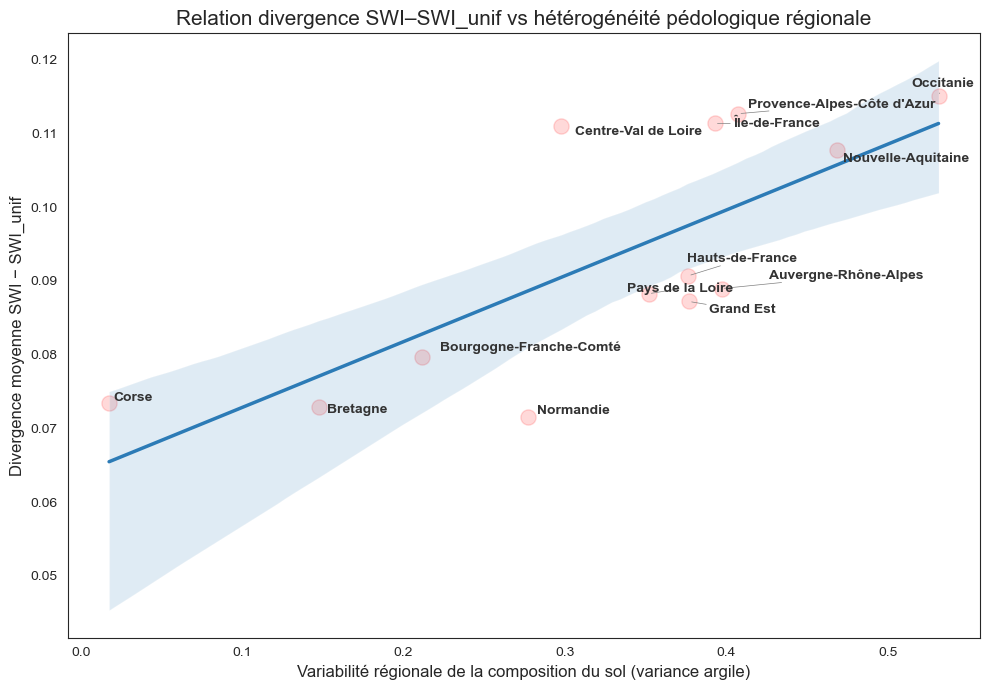

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(10,7))
sns.set_style("white")

# Scatter + regression
ax = sns.regplot(
    data=region_stats,
    x="argile_var",
    y="mae_mean",
    scatter_kws={"s":120, "color":"red"},  # 🔥 couleur plus foncée ici
    line_kws={"color":"#2c7bb6", "linewidth":2.5},
    ci=95
)

# Ajouter les labels avec ajustement automatique
texts = []
for _, row in region_stats.iterrows():
    texts.append(
        plt.text(
            row["argile_var"],
            row["mae_mean"],
            row["nom_region"],
            fontsize=10,
            weight="bold",
            color="#333333"
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Titres + axes
ax.set_xlabel("Variabilité régionale de la composition du sol (variance argile)", fontsize=12)
ax.set_ylabel("Divergence moyenne SWI − SWI_unif", fontsize=12)
ax.set_title("Relation divergence SWI–SWI_unif vs hétérogénéité pédologique régionale", fontsize=15)

# Rendre la bande plus légère
for collection in ax.collections:
    if hasattr(collection, "set_alpha"):
        collection.set_alpha(0.15)

plt.tight_layout()
plt.show()


In [28]:
LimitAdmin = r"D:\ENSAE Paris\3A\S1\ML_Climate_risk\Nouveau dossier\Bases\ADE_4-0_GPKG_LAMB93_FXX-ED2025-10-15.gpkg"
gdf_commune = gpd.read_file(LimitAdmin, layer="commune").to_crs(2154)

In [29]:
gdf_commune.head()

,cleabs,nom_officiel,nom_officiel_en_majuscules,statut,code_insee,population,date_du_recensement,organisme_recenseur,code_insee_du_canton,code_insee_de_l_arrondissement,code_insee_du_departement,code_insee_de_la_region,codes_siren_des_epci,code_siren,code_postal,superficie_cadastrale,geometry
0,COMMUNE_0000000000001001,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,Commune simple,01001,859,2022-01-01,INSEE,0108,012,01,84,200069193,210100012,01400,1590,"MULTIPOLYGON (((851129.6 6563369.2, 851107.5 6..."
1,COMMUNE_0000000000001002,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,Commune simple,01002,273,2022-01-01,INSEE,0101,011,01,84,240100883,210100020,01640,920,"MULTIPOLYGON (((888109.7 6545455.9, 888102.9 6..."
2,COMMUNE_0000000000001004,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,Commune simple,01004,15554,2022-01-01,INSEE,0101,011,01,84,240100883,210100046,01500,2460,"MULTIPOLYGON (((886593 6540886, 886567.9 65408..."
3,COMMUNE_0000000000001005,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,Commune simple,01005,1917,2022-01-01,INSEE,0122,012,01,84,200042497,210100053,01330,1590,"MULTIPOLYGON (((850413.2 6544061, 850381.8 654..."
4,COMMUNE_0000000000001006,Ambléon,AMBLEON,Commune simple,01006,114,2022-01-01,INSEE,0104,011,01,84,200040350,210100061,01300,590,"MULTIPOLYGON (((899820.1 6520340.2, 899925.2 6..."


In [30]:
print(data.columns.tolist())

['NUMERO', 'LAMBX_93', 'LAMBY_93', 'LAMBX_2', 'LAMBY_2', 'ANNEE', 'code_insee_commune', 'commune', 'code_insee_de_la_region', 'region', 'code_insee_departement', 'departement', 'argile_niveau', 'swi_unif_01', 'swi_unif_02', 'swi_unif_03', 'swi_unif_04', 'swi_unif_05', 'swi_unif_06', 'swi_unif_07', 'swi_unif_08', 'swi_unif_09', 'swi_unif_10', 'swi_unif_11', 'swi_unif_12', 'SWI_01', 'SWI_02', 'SWI_03', 'SWI_04', 'SWI_05', 'SWI_06', 'SWI_07', 'SWI_08', 'SWI_09', 'SWI_10', 'SWI_11', 'SWI_12', 'DLI_01', 'DLI_02', 'DLI_03', 'DLI_04', 'DLI_05', 'DLI_06', 'DLI_07', 'DLI_08', 'DLI_09', 'DLI_10', 'DLI_11', 'DLI_12', 'DRAINC_01', 'DRAINC_02', 'DRAINC_03', 'DRAINC_04', 'DRAINC_05', 'DRAINC_06', 'DRAINC_07', 'DRAINC_08', 'DRAINC_09', 'DRAINC_10', 'DRAINC_11', 'DRAINC_12', 'ECOULEMENT_01', 'ECOULEMENT_02', 'ECOULEMENT_03', 'ECOULEMENT_04', 'ECOULEMENT_05', 'ECOULEMENT_06', 'ECOULEMENT_07', 'ECOULEMENT_08', 'ECOULEMENT_09', 'ECOULEMENT_10', 'ECOULEMENT_11', 'ECOULEMENT_12', 'ETP_01', 'ETP_02', 'ETP_0

In [31]:
print(gdf_commune.columns.tolist())

['cleabs', 'nom_officiel', 'nom_officiel_en_majuscules', 'statut', 'code_insee', 'population', 'date_du_recensement', 'organisme_recenseur', 'code_insee_du_canton', 'code_insee_de_l_arrondissement', 'code_insee_du_departement', 'code_insee_de_la_region', 'codes_siren_des_epci', 'code_siren', 'code_postal', 'superficie_cadastrale', 'geometry']


In [32]:
gdf_commune["code_insee"] = gdf_commune["code_insee"].astype(str)
data["code_insee_commune"] = data["code_insee_commune"].astype(str)


In [33]:
geom_communes = gdf_commune[["code_insee", "geometry"]]
import geopandas as gpd

data_geo = data.merge(
    geom_communes,
    left_on="code_insee_commune",
    right_on="code_insee",
    how="left"
)


In [34]:
data_geo = gpd.GeoDataFrame(data_geo, geometry="geometry", crs=gdf_commune.crs)


In [35]:
import pandas as pd
import numpy as np

# --- 1. Colonnes SWI et SWI_unif ---
cols_swi  = [f"SWI_{str(m).zfill(2)}" for m in range(1,13)]
cols_unif = [f"swi_unif_{str(m).zfill(2)}" for m in range(1,13)]

# --- 2. Long format ---
df_long = data_geo.melt(
    id_vars=["code_insee_commune", "commune", "ANNEE", "argile_niveau"],
    value_vars=cols_swi + cols_unif,
    var_name="variable",
    value_name="valeur"
)

df_long["mois"] = df_long["variable"].str[-2:].astype(int)
df_long["type"] = df_long["variable"].str.replace(r"_[0-9]{2}$","", regex=True)

# --- 3. Panel tidy ---
df_panel = df_long.pivot_table(
    index=["code_insee_commune", "commune", "ANNEE", "mois", "argile_niveau"],
    columns="type",
    values="valeur"
).reset_index()

# --- 4. MAE au niveau observation ---
df_panel["abs_diff"] = (df_panel["SWI"] - df_panel["swi_unif"]).abs()


In [36]:
summary_commune = (
    df_panel
    .groupby("code_insee_commune")
    .agg(
        swi_mean       = ("SWI", "mean"),
        swi_std        = ("SWI", "std"),
        swi_unif_mean  = ("swi_unif", "mean"),
        swi_unif_std   = ("swi_unif", "std"),
        argile_mean    = ("argile_niveau", "mean"),
        mae_mean       = ("abs_diff", "mean")
    )
    .reset_index()
)
communes_lookup = data[["code_insee_commune", "commune"]].drop_duplicates()
summary_commune = summary_commune.merge(
    communes_lookup,
    on="code_insee_commune",
    how="left"
)


In [37]:
summary_commune

,code_insee_commune,swi_mean,swi_std,swi_unif_mean,swi_unif_std,argile_mean,mae_mean,commune
0,01010,0.784167,0.241166,0.770208,0.318383,1.0,0.067792,Anglefort
1,01014,0.862778,0.199837,0.827417,0.276167,1.0,0.066194,Arbent
2,01022,0.795833,0.208450,0.770583,0.282525,1.0,0.069500,Artemare
3,01033,0.719583,0.272646,0.683646,0.330903,1.0,0.059104,Valserhône
4,01034,0.745833,0.244557,0.704292,0.309618,1.0,0.059042,Belley
...,...,...,...,...,...,...,...,...
8931,95504,0.604500,0.271330,0.520467,0.298958,3.0,0.086913,Presles
8932,95555,0.585100,0.237738,0.507020,0.298254,1.0,0.100553,Saint-Gratien
8933,95594,0.587200,0.255789,0.517840,0.298806,2.0,0.081713,Seugy
8934,95625,0.560333,0.227184,0.504813,0.296597,2.0,0.097847,Us


In [38]:
summary_commune = summary_commune.merge(
    gdf_commune[["code_insee", "geometry"]],
    left_on="code_insee_commune",
    right_on="code_insee",
    how="left"
)
summary_commune

,code_insee_commune,swi_mean,swi_std,swi_unif_mean,swi_unif_std,argile_mean,mae_mean,commune,code_insee,geometry
0,01010,0.784167,0.241166,0.770208,0.318383,1.0,0.067792,Anglefort,01010,"MULTIPOLYGON (((918167.2 6541319.6, 918189 654..."
1,01014,0.862778,0.199837,0.827417,0.276167,1.0,0.066194,Arbent,01014,"MULTIPOLYGON (((906549.6 6582521.8, 906618.4 6..."
2,01022,0.795833,0.208450,0.770583,0.282525,1.0,0.069500,Artemare,01022,"MULTIPOLYGON (((909303 6532687.8, 909222.9 653..."
3,01033,0.719583,0.272646,0.683646,0.330903,1.0,0.059104,Valserhône,01033,"MULTIPOLYGON (((920665.5 6558075.6, 920643.2 6..."
4,01034,0.745833,0.244557,0.704292,0.309618,1.0,0.059042,Belley,01034,"MULTIPOLYGON (((912173.2 6521101.9, 912153.8 6..."
...,...,...,...,...,...,...,...,...,...,...
8931,95504,0.604500,0.271330,0.520467,0.298958,3.0,0.086913,Presles,95504,"MULTIPOLYGON (((645990.3 6889247.3, 646175.8 6..."
8932,95555,0.585100,0.237738,0.507020,0.298254,1.0,0.100553,Saint-Gratien,95555,"MULTIPOLYGON (((646809.7 6875437.5, 646829.3 6..."
8933,95594,0.587200,0.255789,0.517840,0.298806,2.0,0.081713,Seugy,95594,"MULTIPOLYGON (((655906 6890818.8, 655820.4 689..."
8934,95625,0.560333,0.227184,0.504813,0.296597,2.0,0.097847,Us,95625,"MULTIPOLYGON (((623380 6891563.4, 623402.7 689..."


In [39]:
gdf_commune.head()

,cleabs,nom_officiel,nom_officiel_en_majuscules,statut,code_insee,population,date_du_recensement,organisme_recenseur,code_insee_du_canton,code_insee_de_l_arrondissement,code_insee_du_departement,code_insee_de_la_region,codes_siren_des_epci,code_siren,code_postal,superficie_cadastrale,geometry
0,COMMUNE_0000000000001001,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,Commune simple,01001,859,2022-01-01,INSEE,0108,012,01,84,200069193,210100012,01400,1590,"MULTIPOLYGON (((851129.6 6563369.2, 851107.5 6..."
1,COMMUNE_0000000000001002,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,Commune simple,01002,273,2022-01-01,INSEE,0101,011,01,84,240100883,210100020,01640,920,"MULTIPOLYGON (((888109.7 6545455.9, 888102.9 6..."
2,COMMUNE_0000000000001004,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,Commune simple,01004,15554,2022-01-01,INSEE,0101,011,01,84,240100883,210100046,01500,2460,"MULTIPOLYGON (((886593 6540886, 886567.9 65408..."
3,COMMUNE_0000000000001005,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,Commune simple,01005,1917,2022-01-01,INSEE,0122,012,01,84,200042497,210100053,01330,1590,"MULTIPOLYGON (((850413.2 6544061, 850381.8 654..."
4,COMMUNE_0000000000001006,Ambléon,AMBLEON,Commune simple,01006,114,2022-01-01,INSEE,0104,011,01,84,200040350,210100061,01300,590,"MULTIPOLYGON (((899820.1 6520340.2, 899925.2 6..."


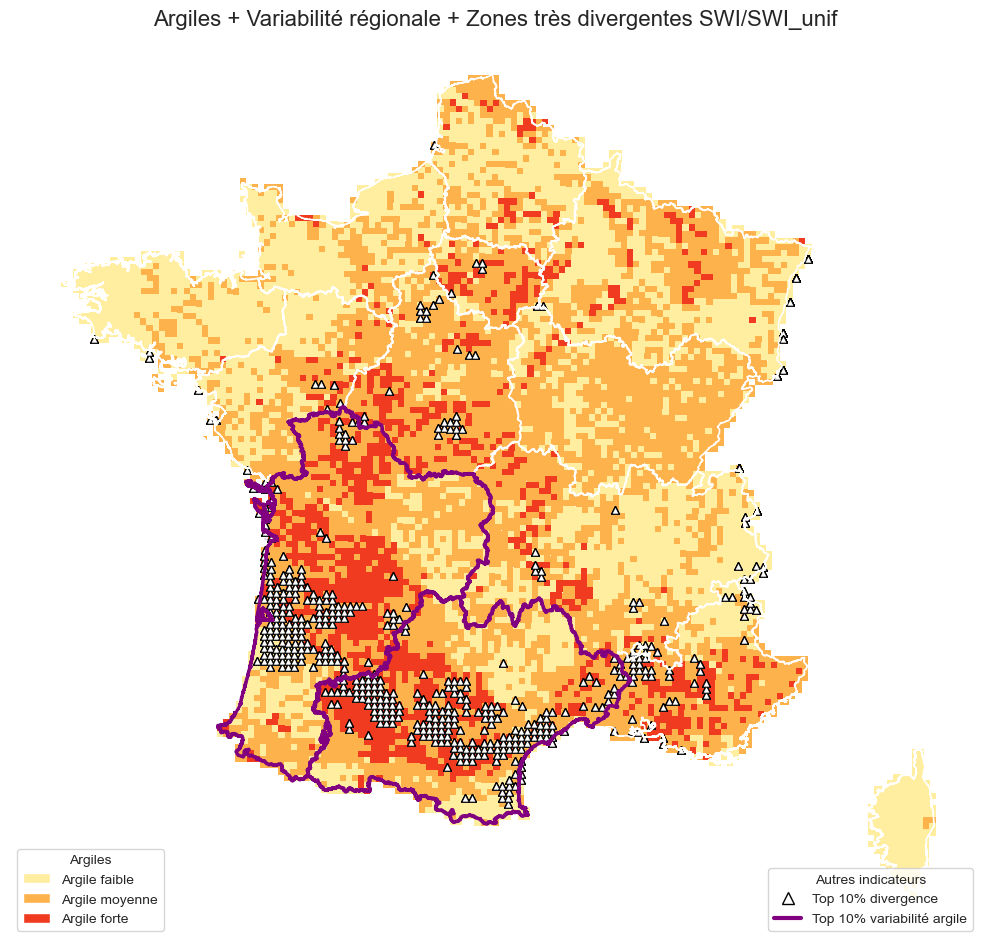

In [40]:
# ============================================================
# 0. Imports
# ============================================================
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# 1. Construire tuiles polygonales
# ============================================================

gdf_pts = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data["LAMBX_93"], data["LAMBY_93"]),
    crs=2154
)

MAILLE = 8000

def make_tile(pt, d):
    x, y = pt.x, pt.y
    return Polygon([(x-d, y-d), (x+d, y-d), (x+d, y+d), (x-d, y+d)])

gdf_tiles = gdf_pts.copy()
gdf_tiles["geometry"] = gdf_pts.geometry.apply(lambda p: make_tile(p, MAILLE/2))


# ============================================================
# 2. Calcul MAE mensuel et annualisé
# ============================================================

cols_swi  = [f"SWI_{str(m).zfill(2)}"      for m in range(1,13)]
cols_unif = [f"swi_unif_{str(m).zfill(2)}" for m in range(1,13)]

df_m = data.melt(
    id_vars=["NUMERO","ANNEE","argile_niveau"],
    value_vars=cols_swi + cols_unif,
    var_name="var",
    value_name="val"
)

df_m["mois"] = df_m["var"].str[-2:].astype(int)
df_m["type"] = df_m["var"].str.replace(r"_[0-9]{2}$","", regex=True)

panel = df_m.pivot_table(
    index=["NUMERO","ANNEE","mois","argile_niveau"],
    columns="type",
    values="val"
).reset_index()

panel["abs_diff"] = (panel["SWI"] - panel["swi_unif"]).abs()

mae = panel.groupby("NUMERO")["abs_diff"].mean().rename("mae").reset_index()
gdf_tiles = gdf_tiles.merge(mae, on="NUMERO", how="left")


# ============================================================
# 3. Couleurs argile (fond identique à ton image)
# ============================================================

cmap_arg = mcolors.ListedColormap(["#FFEDA0", "#FEB24C", "#F03B20"])
norm_arg = mcolors.BoundaryNorm([1,2,3,4], cmap_arg.N)


# ============================================================
# 4. Top 10% divergences → triangles
# ============================================================

seuil_div = gdf_tiles["mae"].quantile(0.90)
gdf_div = gdf_tiles[gdf_tiles["mae"] >= seuil_div].copy()
gdf_div["centroid"] = gdf_div.geometry.centroid


# ============================================================
# 5. Variabilité régionale argile (depuis region_stats)
# ============================================================

# On prépare region_stats
region_stats["code_insee_de_la_region"] = region_stats["code_insee_de_la_region"].astype(str)

# Charger régions
gdf_regions = gpd.read_file(LimitAdmin, layer="region").to_crs(2154)
gdf_regions["code_insee"] = gdf_regions["code_insee"].astype(str)

# Merge variance argile dans la géométrie régionale
gdf_regions = gdf_regions.merge(region_stats[["code_insee_de_la_region","argile_var"]],
                                left_on="code_insee",
                                right_on="code_insee_de_la_region",
                                how="left")

# Top 10% variabilité
seuil_var = gdf_regions["argile_var"].quantile(0.90)
gdf_regions["is_top_var"] = gdf_regions["argile_var"] >= seuil_var


# ============================================================
# 6. CARTE FINALE (sans corrélation)
# ============================================================

fig, ax = plt.subplots(1,1, figsize=(10,11))

# ---- Fond argile (identique à ton image) ----
gdf_tiles.plot(
    ax=ax,
    column="argile_niveau",
    cmap=cmap_arg,
    norm=norm_arg,
    linewidth=0
)

# ---- Frontières régionales classiques ----
gdf_regions.boundary.plot(ax=ax, color="white", linewidth=1.2)

# ---- Surbrillance des régions les plus variables ----
gdf_regions[gdf_regions["is_top_var"]].boundary.plot(
    ax=ax, color="purple", linewidth=2.5, label="Top variabilité argile"
)

# ---- Triangles divergence ----
ax.scatter(
    gdf_div["centroid"].x,
    gdf_div["centroid"].y,
    marker="^",
    s=28,
    facecolor="white",
    edgecolor="black",
    linewidth=0.7,
    label="Top 10% divergence"
)

# ---- Titres ----
ax.set_title("Argiles + Variabilité régionale + Zones très divergentes SWI/SWI_unif",
             fontsize=16)
ax.axis("off")

# ---- Légende argile ----
legend_arg = [
    Patch(facecolor="#FFEDA0", label="Argile faible"),
    Patch(facecolor="#FEB24C", label="Argile moyenne"),
    Patch(facecolor="#F03B20", label="Argile forte"),
]
leg1 = ax.legend(handles=legend_arg, title="Argiles", loc="lower left")

# ---- Légende divergence + variabilité ----
legend_extra = [
    Line2D([0], [0], marker="^", color="black", markerfacecolor="white",
           markersize=8, linestyle="", label="Top 10% divergence"),
    Line2D([0], [0], color="purple", linewidth=3, label="Top 10% variabilité argile")
]
ax.legend(handles=legend_extra, title="Autres indicateurs", loc="lower right")
ax.add_artist(leg1)

plt.tight_layout()
plt.show()
